In [1]:
import numpy as np
import torch
from huggingface_hub import notebook_login
from datasets import load_dataset, load_metric 
from transformers import (AutoFeatureExtractor, 
    AutoModelForImageClassification, 
    TrainingArguments, 
    Trainer,
    pipeline,
    AdamW,
    get_scheduler
)
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)
from PIL import Image
import requests
import matplotlib.pyplot as plt
from pynvml import *
from sam import SAM, SAM_old
import random
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb
import os

In [2]:
#Weights and biases 
#wandb.init(project="vit_SAM")

In [3]:
torch.cuda.empty_cache() #Clear GPU memory

In [4]:
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

In [5]:
model_checkpoint = "WinKawaks/vit-tiny-patch16-224"
batch_size = 32

In [6]:
#notebook_login()

### Load Dataset

In [7]:
dataset = load_dataset("imagefolder", data_dir="NWPU-RESISC45_original")

Resolving data files:   0%|          | 0/31500 [00:00<?, ?it/s]

Using custom data configuration default-c97aeb8aa5f5773e
Reusing dataset imagefolder (/home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597)


  0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
acc = load_metric("accuracy")

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 31500
    })
})

Access an example from the dataset:
1. Select a split
2. Give an index
3. View image (and resize) and check labels

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7FB0F466B640>, 'label': 21}
21


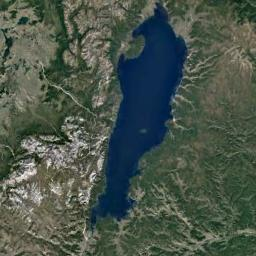

In [10]:
example = dataset["train"][15000]
print(example)
print(example['label'])
example['image']

Huggingface encoded the labels into integers for convenience.
Create dictionary to obtain string label from integer id.

In [11]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[21]

'lake'

### Preprocess Data

Resize images + normalize the RGB colour channels using mean and st dev - image transformations.
We will not conduct data augmentations at the moment.

AutoFeatureExtractor.from_pretrained allows us to obtain the correct sizes, means, and st devs for the model architecture.

In [12]:
feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint)
feature_extractor

ViTFeatureExtractor {
  "do_normalize": true,
  "do_resize": true,
  "feature_extractor_type": "ViTFeatureExtractor",
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "size": 224
}

In [13]:
example['image'].size

(256, 256)

In [14]:
normalize = Normalize(mean = feature_extractor.image_mean, std = feature_extractor.image_std)

transforms = Compose(
        [
            Resize(feature_extractor.size),
            ToTensor()
        ])

def preprocess(batch):
    """Apply transforms across a batch."""
    batch["pixel_values"] = [
        transforms(image.convert("RGB")) for image in batch["image"] 
    ]
    return batch

If we conducted data augmentations (e.g. random flips, random crops), we would have two preprocessing functions - one for train, one for validation. We would not apply augmentations to the validation set.

In [15]:
dataset["train"].set_transform(preprocess)

#Split the training set into train + validation
splits = dataset["train"].train_test_split(test_size = 0.1, seed=0)
train_ds = splits["train"]
val_ds = splits["test"]
#If conducting augmentations, the set_transform would go after splitting the dataset - one for train, one for val

Parameter 'transform'=<function preprocess at 0x7fb1635730a0> of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.
Loading cached split indices for dataset at /home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597/cache-dc1307daab9b8135.arrow and /home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597/cache-07c69933d5d366ad.arrow


We have added a 'pixel_values' feature to each data element, as can be seen below.

In [16]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 43,
 'pixel_values': tensor([[[0.4314, 0.4667, 0.5059,  ..., 0.4471, 0.4980, 0.5686],
          [0.4431, 0.4824, 0.5451,  ..., 0.4941, 0.5451, 0.5647],
          [0.4706, 0.5216, 0.6000,  ..., 0.5373, 0.5765, 0.5647],
          ...,
          [0.3098, 0.2863, 0.2471,  ..., 0.2549, 0.1961, 0.1882],
          [0.3216, 0.3176, 0.2941,  ..., 0.2000, 0.2078, 0.2510],
          [0.2039, 0.2667, 0.3020,  ..., 0.1804, 0.2275, 0.2941]],
 
         [[0.4353, 0.4706, 0.5098,  ..., 0.4667, 0.5137, 0.5843],
          [0.4471, 0.4863, 0.5490,  ..., 0.5137, 0.5647, 0.5804],
          [0.4745, 0.5255, 0.6039,  ..., 0.5608, 0.6000, 0.5843],
          ...,
          [0.3216, 0.2980, 0.2588,  ..., 0.2824, 0.2196, 0.2196],
          [0.3333, 0.3294, 0.3059,  ..., 0.2353, 0.2392, 0.2863],
          [0.2157, 0.2745, 0.3098,  ..., 0.2235, 0.2706, 0.3373]],
 
         [[0.4118, 0.4471, 0.4863,  ..., 0.4471, 0.5098, 0.5882],
 

In [17]:
tensor_img = train_ds[0]["pixel_values"]

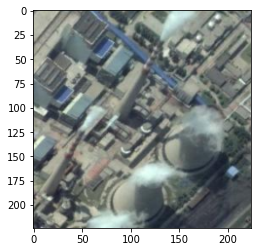

In [18]:
#Permute to put rgb channels as last dimension (tensors have them first)
plt.imshow(tensor_img.permute(1, 2, 0))

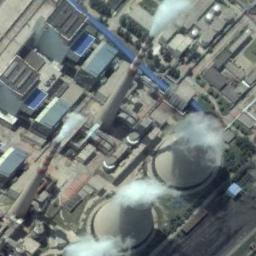

In [19]:
train_ds[0]["image"]

### Train Model

In [20]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True #fine-tuning an already fine-tuned checkpoint
)
#The ViT from Google was pre-trained on ImageNet-21k and then fine-tuned on ImageNet 2012. As we are
#fine-tuning on another dataset, we must ignore the old output head and replace it with a new,
#randomly-initialised classification head with a custom number of output neurons, specific to RESISC45

Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-tiny-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([45, 192]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([45]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Function to compute metrics from the predictions. Will just use 'acc' from before, but preprocess by taking argmax of predicted logits.

In [21]:
def compute_acc(eval_pred):
    """Compute accuracy on batch of predictions."""
    preds = np.argmax(eval_pred.predictions, axis=1)
    return acc.compute(predictions=preds, references=eval_pred.label_ids)

collate_fn will be used to batch examples together, where each batch consists of 2 keys: pixel_values and labels.

In [22]:
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [23]:
#GPU
def print_gpu_utilization():
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")


def print_summary(result):
    print(f"Time: {result.metrics['train_runtime']:.2f}")
    print(f"Samples/second: {result.metrics['train_samples_per_second']:.2f}")
    print_gpu_utilization()

------------------------------------------------------------------------------------------------------------------

Manual training loop, without using Trainer class.

Create pytorch dataloaders from datasets, which incorporate batches

In [24]:
train_dataloader = DataLoader(
        train_ds, shuffle=True, batch_size=batch_size, collate_fn=collate_fn
)

eval_dataloader = DataLoader(
        val_ds, batch_size=batch_size, collate_fn=collate_fn
)

Check that passing a batch to the model actually works

In [25]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'pixel_values': torch.Size([32, 3, 224, 224]), 'labels': torch.Size([32])}

In [26]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(5.9872, grad_fn=<NllLossBackward0>) torch.Size([32, 45])


Set optimizer

In [27]:
base_optimizer = AdamW
optimizer = SAM_old(model.parameters(), base_optimizer, GSAM=True, lr=5e-5)

/home/jeevan/myrtle-vision/classification/venv/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Set learning rate scheduler

In [28]:
num_epochs = 7
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [29]:
#for i in range(10):
#    print(lr_scheduler.get_last_lr())
#    lr_scheduler.step()

Set device to GPU if available

In [30]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
device

device(type='cuda')

In [31]:
torch.cuda.empty_cache() #Free memory

Now training loop

In [32]:
progress_bar = tqdm(range(num_training_steps)) #Progress bar
metric = load_metric("accuracy") #Load accuracy metric for evaluation

model.train() #Tells model that you are training - some layers (e.g. dropout, batchnorm) act differently
#between training and testing
for _ in range(num_epochs): #Iterate over number of epochs
    model.train()
    for batch in train_dataloader: #Iterate over batches
        batch = {k: v.to(device) for k, v in batch.items()} #Get batch
        outputs = model(**batch) #Pass batch through model and obtain output
        loss = outputs.loss #Update loss based on new outputs from model - use this loss for any train stats
        #wandb.log({"loss": loss})
        loss.backward() #Compute dloss/dp for every parameters, p.
        optimizer.first_step(zero_grad=True) #Perturb weights of model
        
        outputs = model(**batch) #Get output of model for batch based on perturbed weights
        loss = outputs.loss #Update loss based on outputs
        loss.backward() #Gradient of loss
        optimizer.second_step(zero_grad=True) #Unperturb weights and update based on perturbed losses
        
        optimizer.zero_grad() #Sets gradient of all optimized tensors to zero
        lr_scheduler.step() #Get next learning rate
        progress_bar.update(1) #Update progress bar
        torch.cuda.empty_cache() #Clear GPU memory
        
    model.eval() #Tell model that you are evaluating
    for val_batch in eval_dataloader: #Iterate over validation batches
        val_batch = {k: v.to(device) for k, v in val_batch.items()}
        with torch.no_grad():
            outputs = model(**val_batch) #Get outputs from model for batch

        logits = outputs.logits #Get logits
        predictions = torch.argmax(logits, dim=-1) #Get pred = argmax of logits
        metric.add_batch(predictions=predictions, references=val_batch["labels"])

    acc = metric.compute() #Display metrics
    print(acc)
    #wandb.log(acc)
    #wandb.watch(model, log='all')

  0%|          | 0/6202 [00:00<?, ?it/s]

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [ ]:
#model_dir = 'hf_vit_tiny_sam'
#os.makedirs(model_dir, exist_ok=True)
#model.save_pretrained(model_dir)

In [ ]:
#wandb.finish()